In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn wordcloud

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [1]:
# importing libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# style
sns.set_style("whitegrid")

# it is used to change the appearance of graphs

In [2]:
# loading data set 
# first downloaded it from provided link 
# then added the downloaded file in the folder made in notebook 
# now loading it 

df = pd.read_csv("spam.csv", encoding="latin-1")



In [3]:
# keeping only required columns

df = df[['v1', 'v2']]



In [4]:
# renaming the  columns
df.columns = ['label', 'message']

print("Dataset Loaded Successfully")
print()

Dataset Loaded Successfully



In [5]:
# overview of the data set 

print("Shape of Dataset:")
print(df.shape)
print()

print("Columns:")
print(df.columns)
print()

print("Info:")
print(df.info())
print()

print("First 5 rows:")
print(df.head())
print()

Shape of Dataset:
(5572, 2)

Columns:
Index(['label', 'message'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

First 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...



In [6]:
# We already know there is no null value using function info() 
# but there is a proper function used only to check whether there is any missing value or not so, we are using that function now

print("Missing Values:")
print(df.isnull().sum())
print()

Missing Values:
label      0
message    0
dtype: int64



Spam/Ham Count:
label
ham     4825
spam     747
Name: count, dtype: int64



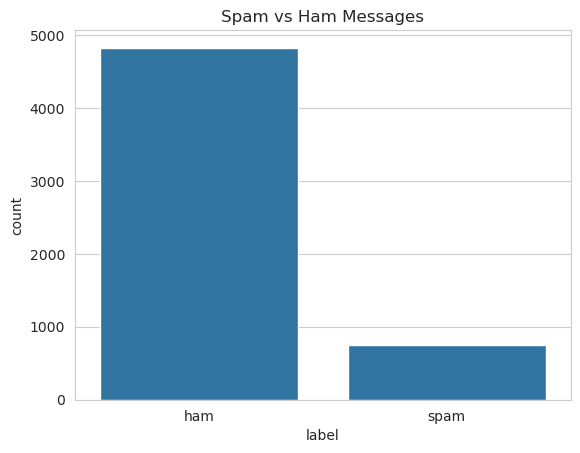

In [7]:
# now label distribution 

print("Spam/Ham Count:")
print(df['label'].value_counts())
print()

sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Messages")
plt.show()

In [8]:
# Now, we will check the message length making a statistical summary

df['length'] = df['message'].apply(len)

print("Message Length Statistical Summary:")
print(df['length'].describe())
print()

print("Median:", df['length'].median())
print("Mean:", df['length'].mean())
print("Standard Deviation:", df['length'].std())
print()

Message Length Statistical Summary:
count    5572.000000
mean       80.118808
std        59.690841
min         2.000000
25%        36.000000
50%        61.000000
75%       121.000000
max       910.000000
Name: length, dtype: float64

Median: 61.0
Mean: 80.11880832735105
Standard Deviation: 59.6908407765031



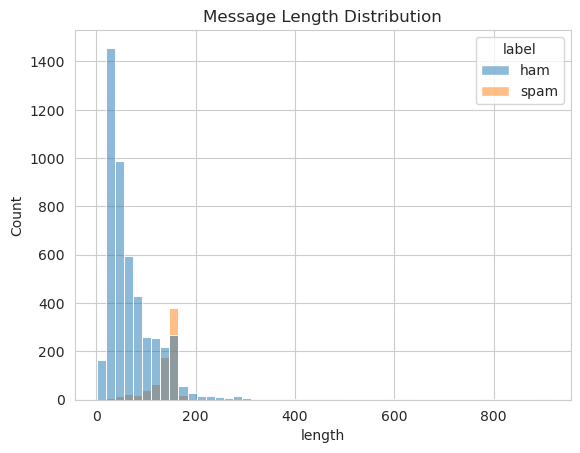

In [9]:
# Now, we will use histogram 
# Histogram is a graphical tool used to show the frequency distribution of numerical data 

sns.histplot(
    data=df,
    x='length',
    hue='label',
    bins=50
)

plt.title("Message Length Distribution")
plt.show()

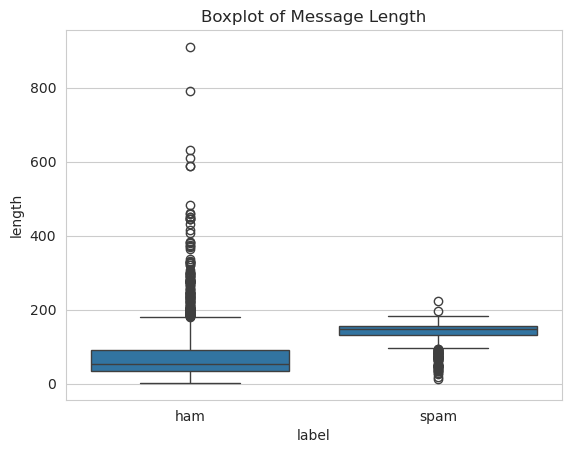

In [10]:
# Now, we will use box plot
# Box plot visually summarizes a data set by displaying its central tendency, spread, and potential outliers

sns.boxplot(
    x='label',
    y='length',
    data=df
)

plt.title("Boxplot of Message Length")
plt.show()

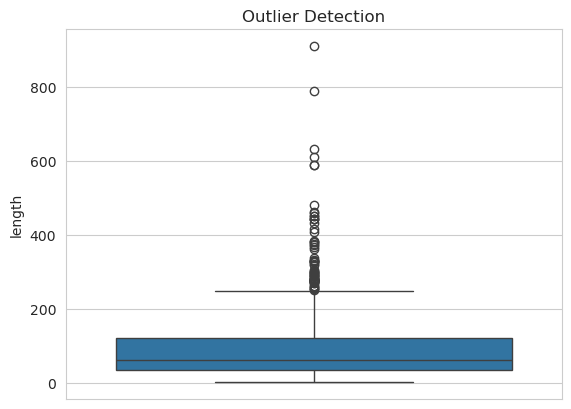

In [11]:
# Now, we are using outlier detection 
# Outlier Detection is the process of identifying data points that deviate significantly from the rest of a data set

sns.boxplot(y=df['length'])
plt.title("Outlier Detection")
plt.show()

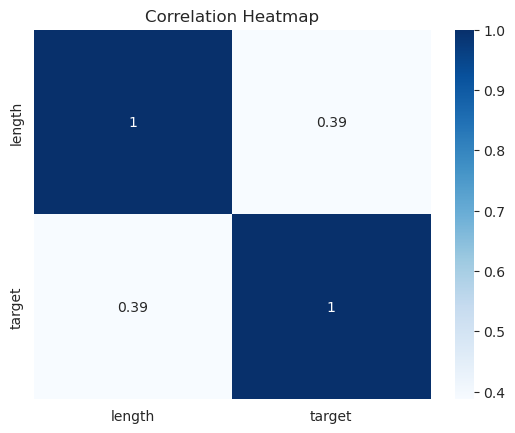

In [12]:
# Now, we are converting labels for correlation analysis 

df['target'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

# Now, we are performing Correlation Analysis
# Correlation Analysis is a statistical method used to evaluate the strength and 
# direction of the relationship between two or more quantitative variables

corr = df[['length', 'target']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")
plt.show()

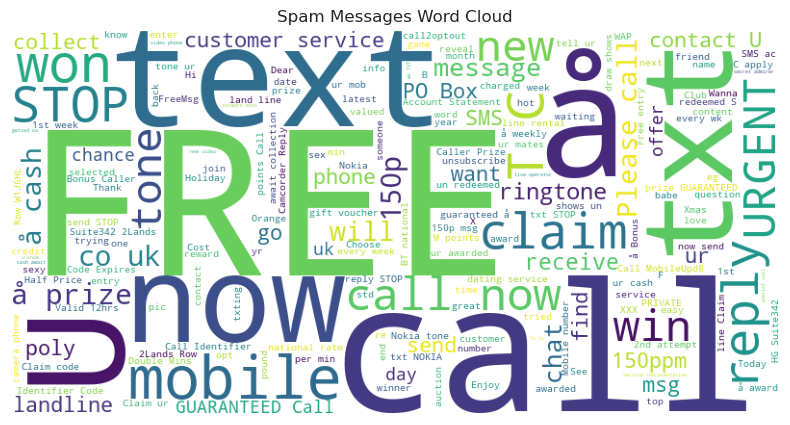

In [13]:
# Now, making word cloud for spam 

spam_words = " ".join(
    df[df['label'] == 'spam']['message']
)

spam_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_words)

plt.figure(figsize=(10, 5))
plt.imshow(spam_wc)
plt.axis('off')
plt.title("Spam Messages Word Cloud")
plt.show()

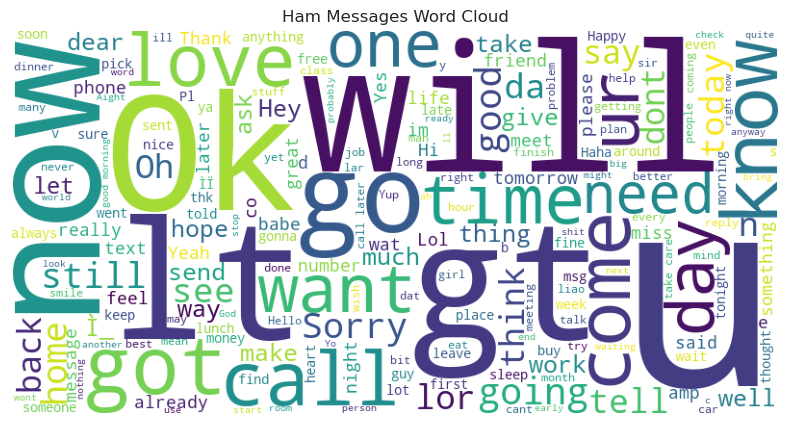

In [14]:
# Now, making word cloud for ham 

ham_words = " ".join(
    df[df['label'] == 'ham']['message']
)

ham_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_words)

plt.figure(figsize=(10, 5))
plt.imshow(ham_wc)
plt.axis('off')
plt.title("Ham Messages Word Cloud")
plt.show()

In [15]:
# Now, we are p r e processing data 
# First, Converting text to numbers using Term Frequency (T F) and Inverse Document Frequency (I D F)

# Term Frequency (T F) measures how often a word appears in a specific document compared to the total number of words 
# in that document

# While, Inverse Document Frequency (I D F) is a statistical metric used in information retrieval 
# and natural language processing to determine how important a word is to a document within a larger collection

X = df['message']
y = df['target']

vectorizer = TfidfVectorizer(
    stop_words='english'
)

X = vectorizer.fit_transform(X)

print("Text Converted using TF-IDF")
print()

# We convert text to numbers using T F - I D F to translate unstructured language into structured numerical data
# Machine learning models and algorithms cannot process raw text

Text Converted using TF-IDF



In [16]:
# Now, we are going to perform ( train - test ) split 
# A train-test split is a machine learning technique used to evaluate the performance of a predictive mode

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train/Test Split Complete")
print()

Train/Test Split Complete



In [17]:
# Now, we are going to use Model 1 - Naive Bayes

# A Naive Bayes model is a probabilistic machine learning classifier based on Bayes' Theorem that assigns a data point to a specific class category

nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

print("Naive Bayes Results")
print()

print("Accuracy:",
      accuracy_score(y_test, pred_nb))

print("Precision:",
      precision_score(y_test, pred_nb))

print("Recall:",
      recall_score(y_test, pred_nb))

print("F1 Score:",
      f1_score(y_test, pred_nb))

print()

print(classification_report(
    y_test,
    pred_nb
))

Naive Bayes Results

Accuracy: 0.968609865470852
Precision: 1.0
Recall: 0.7666666666666667
F1 Score: 0.8679245283018868

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



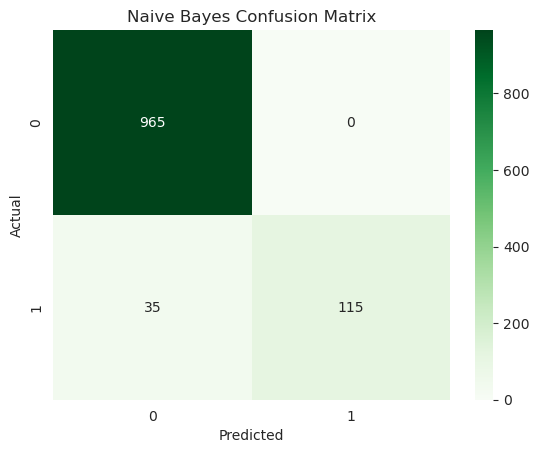

In [18]:
# Confusion Matrix ( Naive Bayes )

# A confusion matrix is a table used to evaluate the performance of a classification model in machine learning

cm_nb = confusion_matrix(
    y_test,
    pred_nb
)

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
# Now, we are going to use Model 2 - Logistic Regression

# Logistic regression is a supervised machine learning algorithm used primarily for classification
# It predicts the probability of a categorical outcome (e.g. yes/no, true/false) based on input variables

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression Results")
print()

print("Accuracy:",
      accuracy_score(y_test, pred_lr))

print("Precision:",
      precision_score(y_test, pred_lr))

print("Recall:",
      recall_score(y_test, pred_lr))

print("F1 Score:",
      f1_score(y_test, pred_lr))

print()

print(classification_report(
    y_test,
    pred_lr
))

Logistic Regression Results

Accuracy: 0.9443946188340807
Precision: 0.9680851063829787
Recall: 0.6066666666666667
F1 Score: 0.7459016393442623

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       965
           1       0.97      0.61      0.75       150

    accuracy                           0.94      1115
   macro avg       0.96      0.80      0.86      1115
weighted avg       0.95      0.94      0.94      1115



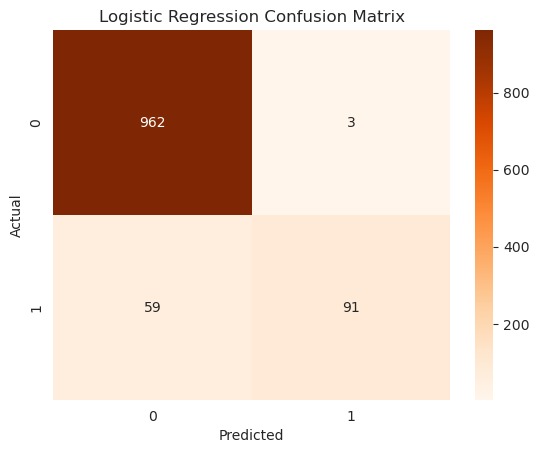

In [20]:
# Confusion Matrix ( Logistic Regression )

# A confusion matrix is a table used to evaluate the performance of a classification model in machine learning

cm_lr = confusion_matrix(
    y_test,
    pred_lr
)

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC-AUC Score:
0.9867081174438688



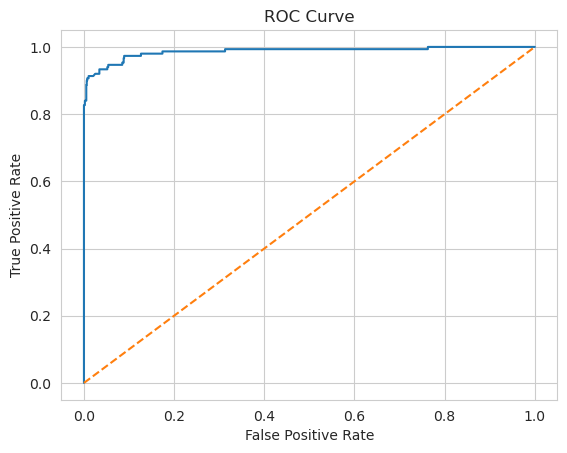

In [21]:
# Now, we are going to use The full form of A U C - R O C 

# A U C - R O C means Area under the Receiver Operating Characteristic Curve
# This metric helps in evaluating the ability of a model to distinguish between positive and negative classes

nb_probs = nb.predict_proba(
    X_test
)[:, 1]

auc_score = roc_auc_score(
    y_test,
    nb_probs
)

print("ROC-AUC Score:")
print(auc_score)
print()

fpr, tpr, thresholds = roc_curve(
    y_test,
    nb_probs
)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [22]:
# Now, we are comparing both models used

comparison = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Logistic Regression'
    ],

    'Accuracy': [
        accuracy_score(y_test, pred_nb),
        accuracy_score(y_test, pred_lr)
    ],

    'Precision': [
        precision_score(y_test, pred_nb),
        precision_score(y_test, pred_lr)
    ],

    'Recall': [
        recall_score(y_test, pred_nb),
        recall_score(y_test, pred_lr)
    ],

    'F1 Score': [
        f1_score(y_test, pred_nb),
        f1_score(y_test, pred_lr)
    ]
})

print("Model Comparison")
print()
print(comparison)
print()

Model Comparison

                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.968610   1.000000  0.766667  0.867925
1  Logistic Regression  0.944395   0.968085  0.606667  0.745902



In [23]:
# Which one is the best model ? Lets check by code :

best = comparison.sort_values(
    by='F1 Score',
    ascending=False
)

print("Best Performing Model:")
print(best.head(1))
print()

Best Performing Model:
         Model  Accuracy  Precision    Recall  F1 Score
0  Naive Bayes   0.96861        1.0  0.766667  0.867925



In [24]:
# Now, lets check some sample data to verify working of our project 

sample_messages = [
    "Congratulations! You won free tickets",
    "Where are you now?",
    "Call me back please",
    "Win cash prize now"
]

sample_vector = vectorizer.transform(
    sample_messages
)

predictions = nb.predict(
    sample_vector
)

print("Sample Predictions")
print()

for msg, pred in zip(
        sample_messages,
        predictions):

    if pred == 1:
        result = "Spam"
    else:
        result = "Ham"

    print(msg, " --> ", result)

Sample Predictions

Congratulations! You won free tickets  -->  Ham
Where are you now?  -->  Ham
Call me back please  -->  Ham
Win cash prize now  -->  Spam


In [2]:
# Hence the predictions are good, which shows the project is working fine 
# The project is complete now 

print()
print("Spam SMS Detection Project Finished Successfully")


Spam SMS Detection Project Finished Successfully
